In [1]:
# Isometric dot paper — three densities (regular / extra / super).
# Triangular dot lattice with basis vectors (P_x, 0) and (P_x/2, P_y).
# Per-density DOT_SIZE matches the dotted scheme (20/12/10) so sparse
# dots stay visible. CENTER_MARGIN=125 is the cross-density invariant;
# dot CENTERS sit on the canonical lattice regardless of dot size.
#
# CONSTRAINT CONFLICT (intentional, documented):
#   A true 60° isometric lattice requires P_y = P_x * sqrt(3)/2, which is
#   irrational — no integer (P_x, P_y) pair gives EXACTLY 60°. We pick the
#   closest integer P_y that ALSO divides LATTICE_H so the bottom margin
#   stays pixel-exact. Angular deviation per density is < 1.2°, visually
#   indistinguishable from true 60° at this resolution.
#
# CONSTRAINTS:
#   - P_x must be EVEN (so the P_x/2 offset on odd rows is an integer).
#   - P_x divides LATTICE_W = 8250 (right margin lands exactly).
#   - P_y divides LATTICE_H = 10500 (bottom margin lands exactly).
#   - Even-row L/R edge-margin = edge_margin(DOT_SIZE).
#   - Odd-row  L/R edge-margin = edge_margin(DOT_SIZE) + P_x/2 (mirror-
#     symmetric, larger by P_x/2 — natural look of triangular paper).
#
# Output: ../output/isometric/{isometric,extra-isometric,super-isometric}.png
import math
from PIL import Image
from IPython.display import display
from common import (
    blank_page, draw_header, make_dot_template, edge_margin,
    LATTICE_W, LATTICE_H, HEADER_HEIGHT,
    output_path, variant_name,
)

MODE = "isometric"

# (P_x, P_y, DOT_SIZE) per density.
ISO = {
    "regular": (250, 210, 20),   # angle 59.24°, dev 0.76°, ratio 20/250=8.0%
    "extra":   (150, 125, 12),   # angle 59.04°, dev 0.96°, ratio 12/150=8.0%
    "super":   (110, 100, 10),   # angle 61.19°, dev 1.19°, ratio 10/110=9.1%
}

In [2]:
def render_isometric(P_x, P_y, dot_size):
    assert P_x % 2 == 0, "P_x must be even"
    assert LATTICE_W % P_x == 0, f"P_x={P_x} must divide LATTICE_W={LATTICE_W}"
    assert LATTICE_H % P_y == 0, f"P_y={P_y} must divide LATTICE_H={LATTICE_H}"
    n_x_even = LATTICE_W // P_x + 1
    n_x_odd  = n_x_even - 1
    n_y      = LATTICE_H // P_y + 1
    half     = P_x // 2
    margin   = edge_margin(dot_size)
    dot      = make_dot_template(size=dot_size)
    img = blank_page()
    for j in range(n_y):
        y = HEADER_HEIGHT + margin + j * P_y
        if j % 2 == 0:
            for i in range(n_x_even):
                img.paste(dot, (margin + i * P_x, y))
        else:
            for i in range(n_x_odd):
                img.paste(dot, (margin + half + i * P_x, y))
    draw_header(img)
    total = ((n_y + 1) // 2) * n_x_even + (n_y // 2) * n_x_odd
    angle = math.degrees(math.atan2(2 * P_y, P_x))
    return img, n_y, total, angle

regular  P_x=250  P_y=210  dot=20  rows= 51  dots= 1709  angle=59.24°  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/isometric/isometric.png


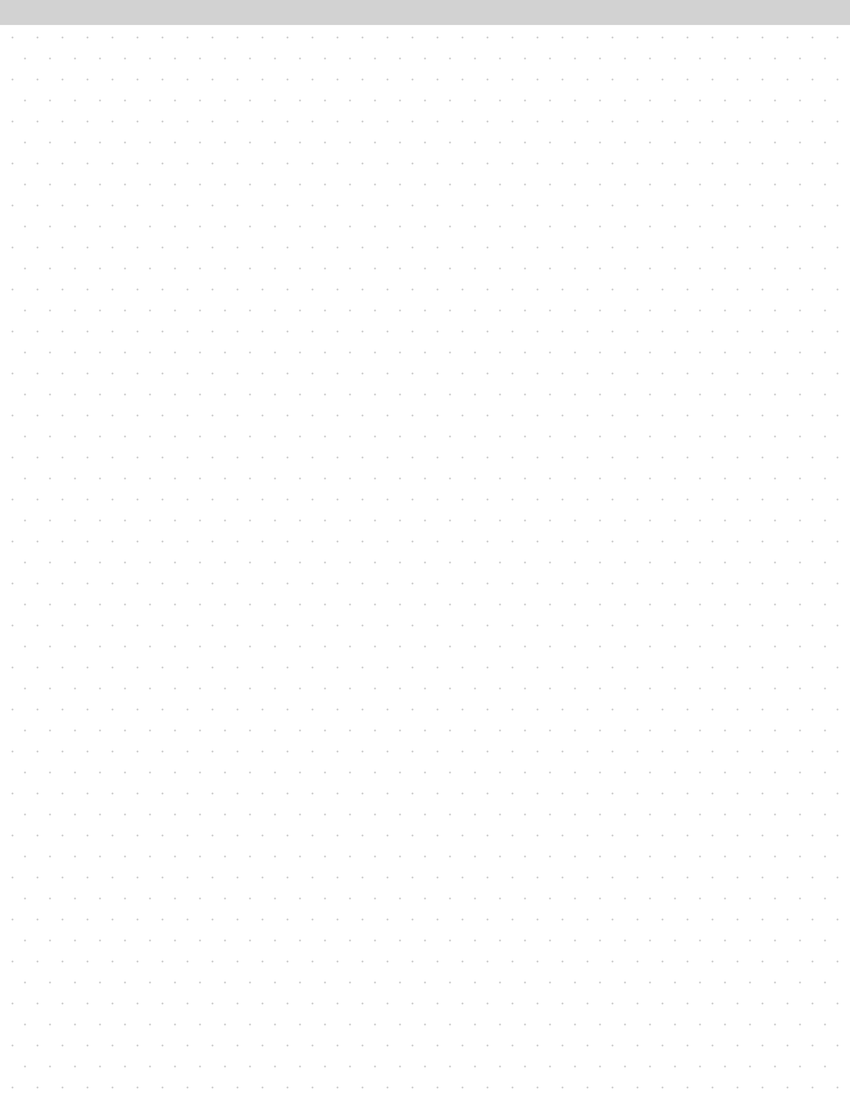

extra    P_x=150  P_y=125  dot=12  rows= 85  dots= 4718  angle=59.04°  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/isometric/extra-isometric.png


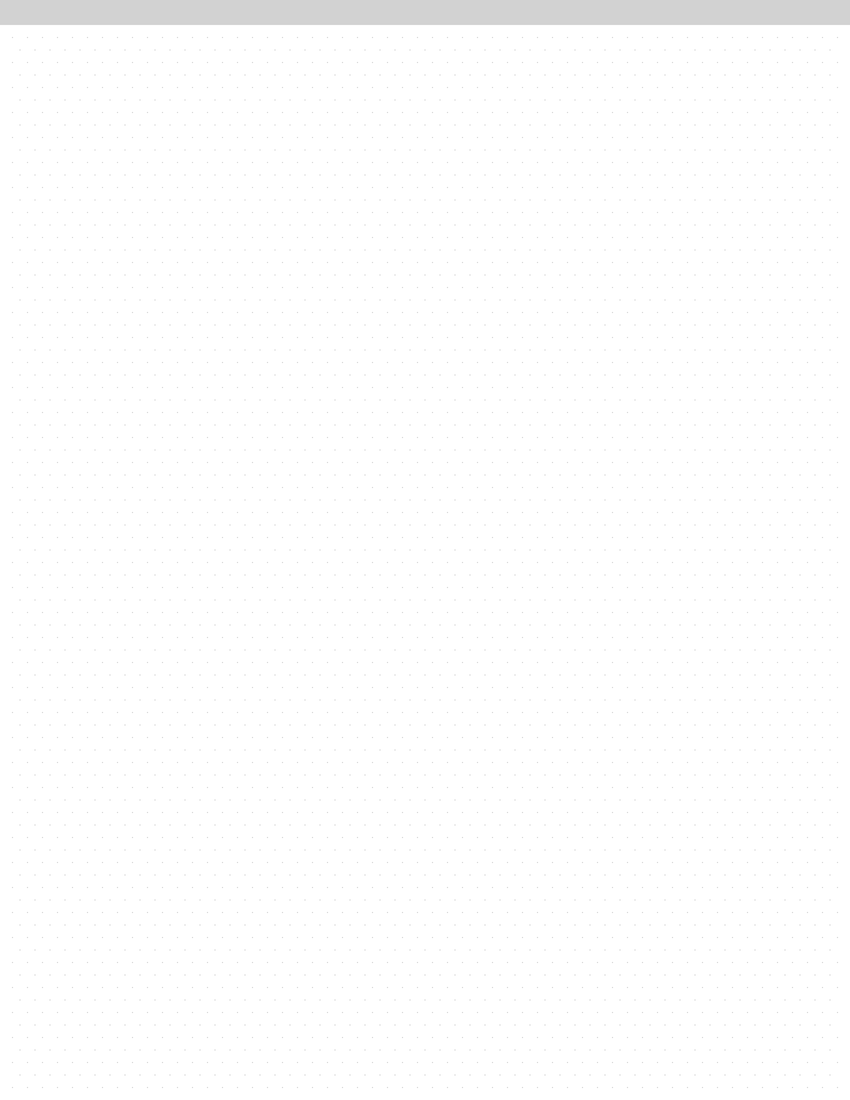

super    P_x=110  P_y=100  dot=10  rows=106  dots= 8003  angle=61.19°  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/isometric/super-isometric.png


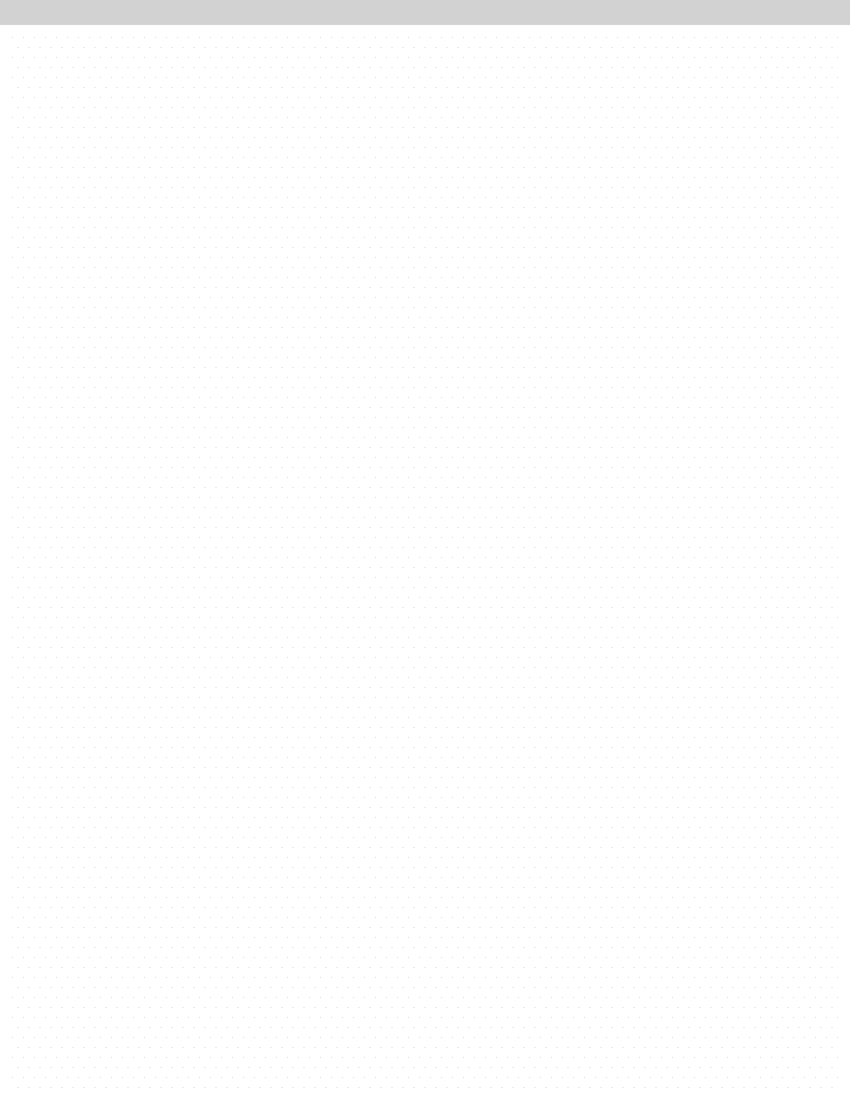

In [3]:
for density, (P_x, P_y, dot_size) in ISO.items():
    img, n_y, total, angle = render_isometric(P_x, P_y, dot_size)
    path = output_path(MODE, variant_name(MODE, density))
    img.save(path, "PNG")
    print(
        f"{density:8s} P_x={P_x:3d}  P_y={P_y:3d}  dot={dot_size:2d}  "
        f"rows={n_y:3d}  dots={total:5d}  angle={angle:.2f}°  →  {path}"
    )
    display(img.resize((850, 1100), Image.LANCZOS))